Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt

from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

Data Collection and Processing

In [2]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('/content/heart_dataset.csv')

In [3]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
# number of rows and columns in the dataset
heart_data.shape

(303, 14)

In [6]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# checking for missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

,count
target,
1,165
0,138


1 --> Defective Heart

0 --> Healthy Heart

Splitting the Features and Target

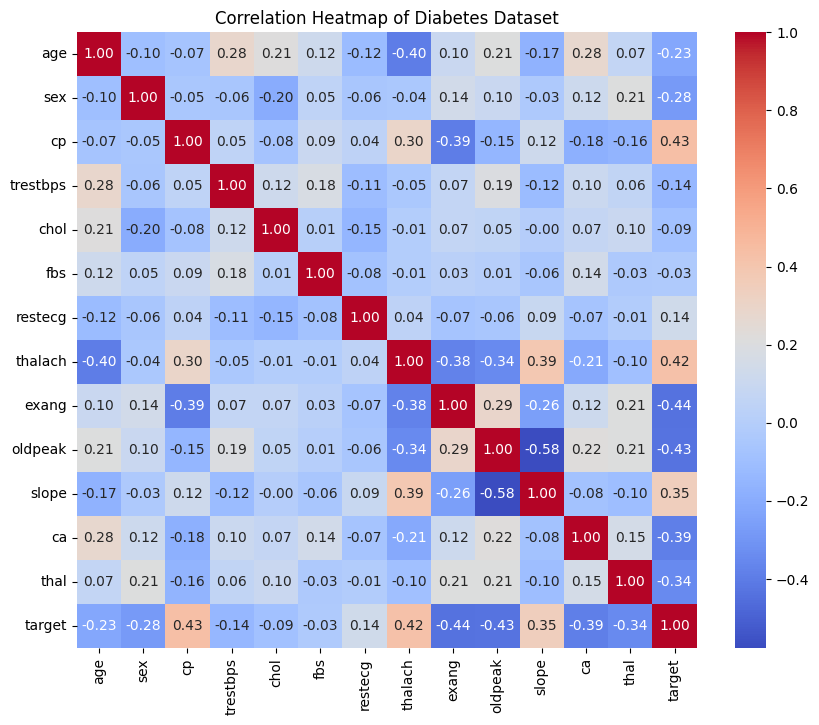

In [10]:
correlation_matrix = heart_data.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

In [11]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [12]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [13]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


Splitting the Data into Training data & Test Data

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [15]:
print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


Model Training

                       Support Vector Machine (SVM)

In [16]:
from sklearn import svm
model = svm.SVC(kernel='linear', probability=True)

In [17]:
# training the SVM model with training data
model.fit(X_train, Y_train)

SVC(kernel='linear', probability=True)

Model Evaluation

Accuracy Score

In [18]:
# accuracy score on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 85.54%


In [19]:
# accuracy score on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the testing data: {formatted_accuracy}')

Accuracy score of the testing data: 81.97%


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

Training Data Metrics:
Accuracy: 85.54%
Precision: 86.25%
Recall: 85.54%
F1 Score: 85.34%

Test Data Metrics:
Accuracy: 81.97%
Precision: 82.14%
Recall: 81.97%
F1 Score: 81.85%


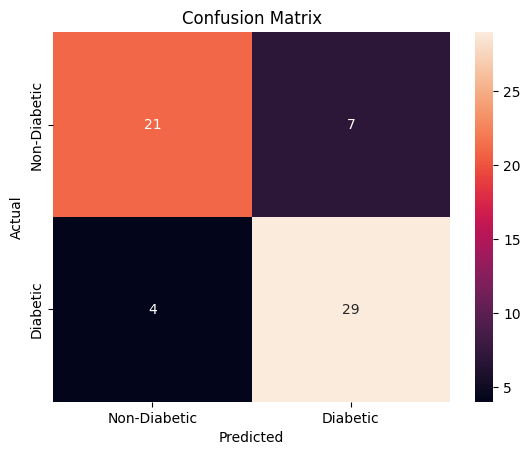

In [21]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CLASSIFICATION REPORT

In [22]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.84      0.75      0.79        28
           1       0.81      0.88      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.81      0.82        61
weighted avg       0.82      0.82      0.82        61



Building a Predictive System

In [23]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


                    Logistic Regression

In [24]:
model2 = LogisticRegression()

In [25]:
# training the LogisticRegression model with Training data
model2.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Model Evaluation

ACCURACY SCORE & CONFUSION MATRIX



Accuracy Score

In [26]:
# accuracy on training data
X_train_prediction = model2.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 85.12%


In [27]:
# accuracy on test data
X_test_prediction = model2.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the testing data: {formatted_accuracy}')

Accuracy score of the testing data: 81.97%


Training Data Metrics:
Accuracy: 85.12%
Precision: 85.45%
Recall: 85.12%
F1 Score: 84.99%

Test Data Metrics:
Accuracy: 81.97%
Precision: 82.05%
Recall: 81.97%
F1 Score: 81.99%


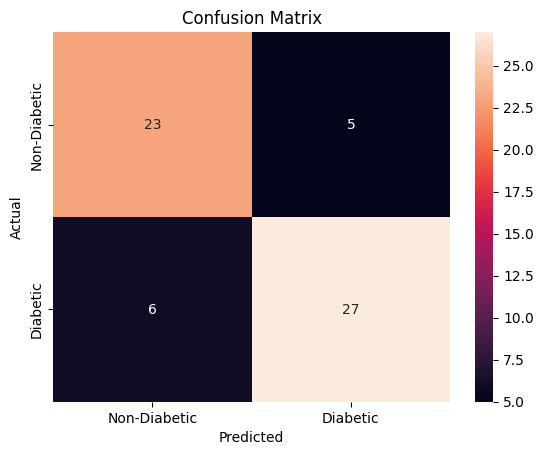

In [28]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CLASSIFICATION REPORT

In [29]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.79      0.82      0.81        28
           1       0.84      0.82      0.83        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



Building a Predictive System

In [30]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model2.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Gradient Boosting

In [31]:
from sklearn.ensemble import GradientBoostingClassifier

model3 = GradientBoostingClassifier(loss='exponential', learning_rate=0.1, n_estimators=200, max_features=None)

In [32]:
# training the GB model with training data
model3.fit(X_train, Y_train)

GradientBoostingClassifier(loss='exponential', n_estimators=200)

Model Evaluation

Accuracy Score

In [33]:
# accuracy score on training data
X_train_prediction = model3.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 100.00%


In [34]:
# accuracy score on testing data
X_test_prediction = model3.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of test data: {formatted_accuracy}')

Accuracy score of test data: 68.85%


Training Data Metrics:
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%

Test Data Metrics:
Accuracy: 68.85%
Precision: 68.96%
Recall: 68.85%
F1 Score: 68.89%


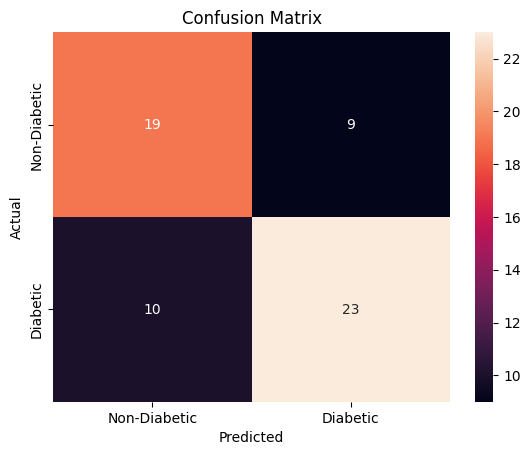

In [35]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CLASSIFICATION REPORT

In [36]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.66      0.68      0.67        28
           1       0.72      0.70      0.71        33

    accuracy                           0.69        61
   macro avg       0.69      0.69      0.69        61
weighted avg       0.69      0.69      0.69        61



Building a Predictive System

Performance Metrics Comparison:
              Model  Accuracy  Precision  Recall  F1-Score
                SVM     81.97      82.14   81.97     81.85
  Gradient Boosting     68.85      68.96   68.85     68.89
Logistic Regression     81.97      82.05   81.97     81.99


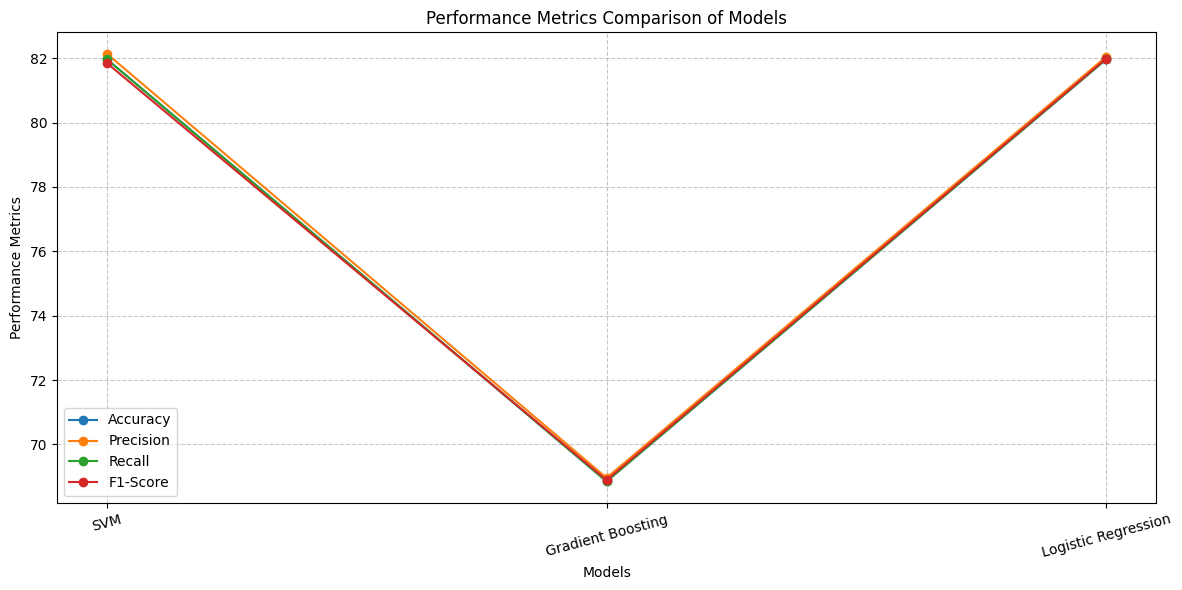

In [40]:
data = {
    'Model': ['SVM', 'Gradient Boosting', 'Logistic Regression'],
    'Accuracy': [81.97, 68.85, 81.97],
    'Precision': [82.14, 68.96, 82.05],
    'Recall': [81.97,  68.85, 81.97],
    'F1-Score': [81.85, 68.89, 81.99]
}

metrics_df = pd.DataFrame(data)

# Display the table
print("Performance Metrics Comparison:")
print(metrics_df.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    plt.plot(metrics_df['Model'], metrics_df[metric], marker='o', linestyle='-', label=metric)

plt.xlabel('Models')
plt.ylabel('Performance Metrics')
plt.title('Performance Metrics Comparison of Models')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [37]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model3.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


Saving the trained model

In [38]:
import pickle

In [39]:
filename = 'heart_disease_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [42]:
# loading the saved model
loaded_model = pickle.load(open('heart_disease_model.sav', 'rb'))

In [43]:
for column in X.columns:
  print(column)

age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal


In [44]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a352e12cc667f5cc2fe6a25553922d38a05fa2001d65756d84524fa6675f7b26
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [45]:
import shap
import lime
import lime.lime_tabular

In [51]:
# SHAP implementation
explainer_shap = shap.Explainer(model.predict, X_test)
shap_values = explainer_shap(X_test)

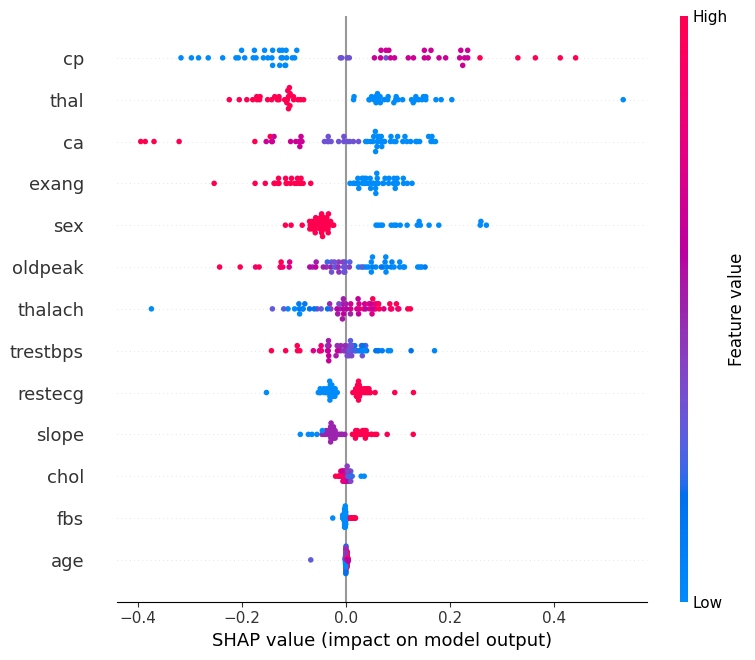

In [52]:
# Summary plot to visualize feature importance using SHAP
shap.summary_plot(shap_values, X_test)

The SHAP summary plot shows how different features impact the model's prediction of heart disease. Features like **cp (chest pain), thal (thalassemia), and ca (major vessels)** have a strong influence. **Higher values of certain features (in red) push the prediction toward heart disease, while lower values (in blue) push it away.** If most SHAP values are positive, the model likely predicts a defective heart; if negative, a healthy heart.

In [65]:
# SHAP Fidelity (Agreement with Model Predictions)
shap_fidelity = np.mean(np.abs(shap_values.values.sum(axis=1) - model.decision_function(X_test)))

# SHAP Interpretability (Avg. Number of Features Contributing)
shap_interpretability = np.mean(np.count_nonzero(shap_values.values, axis=1))

# SHAP Unambiguity (Standard Deviation of Feature Importance)
shap_unambiguity = np.mean(np.std(shap_values.values, axis=0))


In [66]:
print("SHAP XAI Performance Metrics")
print(f"SHAP Fidelity: {shap_fidelity:.4f}")
print(f"SHAP Interpretability (Avg Features Used): {shap_interpretability:.2f}")
print(f"SHAP Unambiguity: {shap_unambiguity:.4f}")

SHAP XAI Performance Metrics
SHAP Fidelity: 1.1418
SHAP Interpretability (Avg Features Used): 12.79
SHAP Unambiguity: 0.0751


In [63]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=['Healthy heart', 'Defective heart'], mode='classification')

In [64]:
sample_index = 0
exp = explainer_lime.explain_instance(X_test.iloc[sample_index].values, model.predict_proba, num_features=len(X_test.columns))

exp.show_in_notebook()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


The model predicts a Healthy Heart with 98% probability and a Defective Heart with only 2% probability. Key factors like low oldpeak (0.00), lower age (45), and other supportive features contribute to this classification. The overall prediction suggests low risk of heart disease.

In [68]:
lime_exp = exp
instance = X_test.iloc[0].values
# LIME Fidelity (Agreement with Model Predictions)
lime_fidelity = np.mean([abs(lime_exp.local_pred[0] - model.predict_proba([instance])[0][0])])

# LIME Interpretability (Number of Features Used)
lime_interpretability = len(lime_exp.as_list())

# LIME Unambiguity (Standard Deviation of Feature Importance)
lime_unambiguity = np.std([abs(weight) for _, weight in lime_exp.as_list()])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [69]:
print("LIME XAI Performance Metrics")
print(f"LIME Fidelity: {lime_fidelity:.4f}")
print(f"LIME Interpretability: {lime_interpretability}")
print(f"LIME Unambiguity: {lime_unambiguity:.4f}")

LIME XAI Performance Metrics
LIME Fidelity: 1.1662
LIME Interpretability: 13
LIME Unambiguity: 0.0840


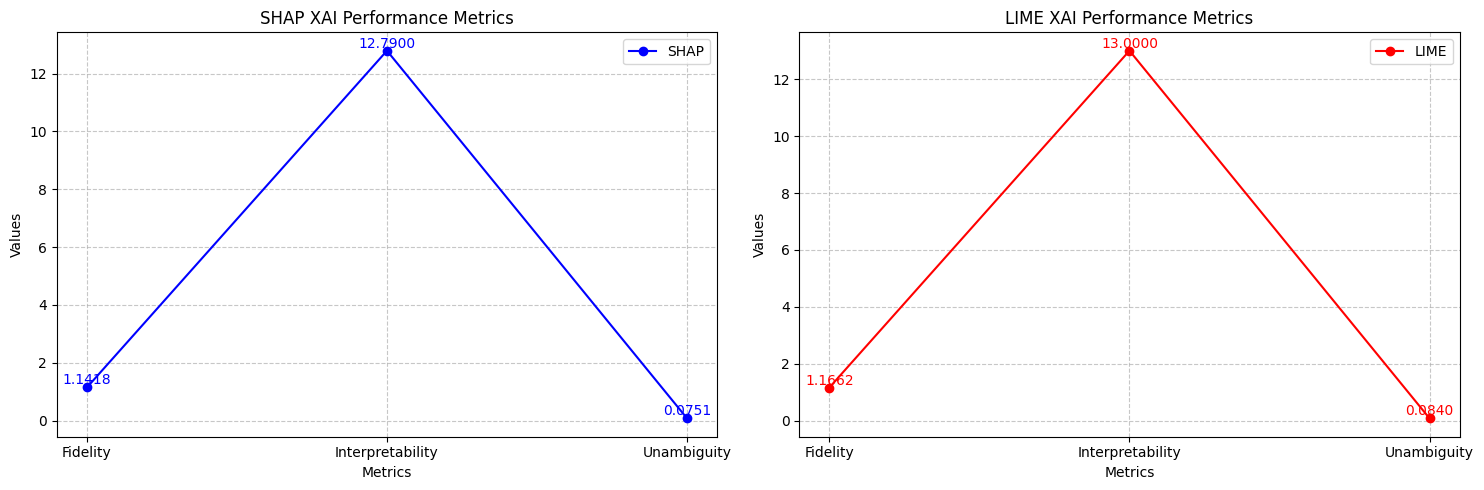

In [70]:
# SHAP and LIME Performance Metrics
data_shap = {
    'Metric': ['Fidelity', 'Interpretability', 'Unambiguity'],
    'Value': [1.1418, 12.79, 0.0751]
}

data_lime = {
    'Metric': ['Fidelity', 'Interpretability', 'Unambiguity'],
    'Value': [1.1662, 13.00, 0.0840]
}

shap_df = pd.DataFrame(data_shap)
lime_df = pd.DataFrame(data_lime)

# Plot SHAP and LIME Metrics Side by Side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# SHAP Plot
axes[0].plot(shap_df['Metric'], shap_df['Value'], marker='o', linestyle='-', color='blue', label='SHAP')
for i, txt in enumerate(shap_df['Value']):
    axes[0].text(i, shap_df['Value'][i], f'{txt:.4f}', ha='center', va='bottom', fontsize=10, color='blue')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Values')
axes[0].set_title('SHAP XAI Performance Metrics')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# LIME Plot
axes[1].plot(lime_df['Metric'], lime_df['Value'], marker='o', linestyle='-', color='red', label='LIME')
for i, txt in enumerate(lime_df['Value']):
    axes[1].text(i, lime_df['Value'][i], f'{txt:.4f}', ha='center', va='bottom', fontsize=10, color='red')
axes[1].set_xlabel('Metrics')
axes[1].set_ylabel('Values')
axes[1].set_title('LIME XAI Performance Metrics')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

Fidelity – How well the explanation method (like SHAP or LIME) represents the actual model’s behavior. Higher fidelity means the explanation is more accurate. (Closer to 1)

Interpretability – How easily a human can understand the explanation. Often measured by the number of features used in an explanation.

Unambiguity – How consistent and clear the explanations are across different instances. Lower unambiguity means more reliable explanations. (Closer to zero)

**Fidelity**

Higher fidelity means the explanation method aligns well with the model's behavior.
LIME has slightly higher fidelity, meaning it represents the model's behavior slightly better.

**Interpretability (Avg Features Used)**

Lower is better (fewer features = simpler explanations).
SHAP is slightly better as it uses fewer features on average.

**Unambiguity (Consistency of Explanations)**

Lower unambiguity means more reliable and consistent explanations.
SHAP is better since it has a lower value, meaning its explanations are more consistent.


SHAP performs better in interpretability (simpler explanations) and unambiguity (more consistent explanations).

LIME has slightly better fidelity, meaning it represents the model slightly better.

Overall, SHAP is a better choice as it provides more consistent and interpretable explanations, which are crucial for understanding model decisions.